# 🚗 Car Price Prediction — Notebook 1: Exploratory Data Analysis (EDA)

---

## 📌 Introduction

### Problem Statement

When someone wants to buy or sell a used car, how do they know the **right price**?  
They look at factors like the car's age, brand, fuel type, and how many kilometres it has been driven.

Our goal is to build a **Machine Learning model** that can predict the selling price of a used car based on these factors.

### Objective

- Understand the dataset thoroughly before touching any model
- Explore the distribution of each feature
- Find relationships between features and the target variable (Price)
- Identify any data quality issues (missing values, outliers, duplicates)

### Why EDA First?

> Think of EDA like a doctor examining a patient before prescribing medicine.  
> You never jump to a solution without first understanding the problem.

Skipping EDA leads to:
- Training models on dirty data
- Missing important patterns
- Poor model performance
- Wrong conclusions

### Dataset Description

| Column | Description |
|--------|-------------|
| `name` | Full model name of the car |
| `company` | Manufacturer / brand of the car |
| `year` | Year the car was manufactured |
| `Price` | Selling price of the car (Target Variable) |
| `kms_driven` | Total kilometres driven by the car |
| `fuel_type` | Type of fuel used (Petrol / Diesel / LPG) |

---
## 📦 Step 1: Import Libraries

We import the tools we need for data analysis and visualization.

- **pandas** — for loading and manipulating data
- **numpy** — for numerical operations
- **matplotlib** — for basic plotting
- **seaborn** — for beautiful statistical plots

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style so our graphs look clean and professional
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Suppress unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


---
## 📂 Step 2: Load the Dataset

We load the cleaned CSV file into a pandas DataFrame.  
A **DataFrame** is like a table in Excel — rows are records, columns are features.

In [2]:
# Load the cleaned dataset
# '../data/cleaned_car.csv' means: go one folder up, then into 'data' folder
df = pd.read_csv('../data/cleaned_car.csv')

print('Dataset loaded successfully!')
print(f'Total rows    : {df.shape[0]}')
print(f'Total columns : {df.shape[1]}')

Dataset loaded successfully!
Total rows    : 725
Total columns : 6


### 2.1 — First 5 Rows (`head()`)

`head()` shows the first 5 rows.  
This gives us a quick preview of what the data looks like — column names, data values, and structure.

In [3]:
# Display the first 5 rows of the dataset
print('First 5 rows of the dataset:')
df.head()

First 5 rows of the dataset:


,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,425000,40,Diesel
2,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,325000,28000,Petrol
3,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,575000,36000,Diesel
4,Ford Figo,Ford,2012,175000,41000,Diesel


### 2.2 — Last 5 Rows (`tail()`)

`tail()` shows the last 5 rows.  
Useful for checking if the data ends cleanly or has any trailing garbage rows.

In [4]:
# Display the last 5 rows of the dataset
print('Last 5 rows of the dataset:')
df.tail()

Last 5 rows of the dataset:


,name,company,year,Price,kms_driven,fuel_type
720,Maruti Suzuki Ritz VXI ABS,Maruti,2011,270000,50000,Petrol
721,Tata Indica V2 DLE BS III,Tata,2009,110000,30000,Diesel
722,Toyota Corolla Altis,Toyota,2009,300000,132000,Petrol
723,Tata Zest XM Diesel,Tata,2018,260000,27000,Diesel
724,Mahindra Quanto C8,Mahindra,2013,390000,40000,Diesel


---
## 🔍 Step 3: Dataset Information

### 3.1 — `info()` — Column Types and Non-Null Counts

`info()` tells us:
- The **data type** of each column (int, float, object)
- How many **non-null values** exist per column
- Memory usage of the dataframe

> **object** dtype = text/string data  
> **int64** dtype = whole numbers  
> **float64** dtype = decimal numbers

In [5]:
# Display column types and non-null counts
print('Dataset Information:')
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 725 entries, 0 to 724
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        725 non-null    object
 1   company     725 non-null    object
 2   year        725 non-null    int64 
 3   Price       725 non-null    int64 
 4   kms_driven  725 non-null    int64 
 5   fuel_type   725 non-null    object
dtypes: int64(3), object(3)
memory usage: 34.1+ KB


### 3.2 — `describe()` — Statistical Summary

`describe()` shows summary statistics for **numerical columns**:

| Statistic | Meaning |
|-----------|----------|
| `count` | Number of non-null values |
| `mean` | Average value |
| `std` | Standard deviation (how spread out the data is) |
| `min` | Minimum value |
| `25%` | First quartile (25% of data is below this) |
| `50%` | Median (middle value) |
| `75%` | Third quartile (75% of data is below this) |
| `max` | Maximum value |

In [6]:
# Display statistical summary for numerical columns
print('Statistical Summary of Numerical Columns:')
df.describe()

Statistical Summary of Numerical Columns:


,year,Price,kms_driven
count,725.000000,7.250000e+02,725.000000
mean,2012.317241,3.925164e+05,46762.664828
std,4.121939,3.741623e+05,34560.157448
min,1995.000000,3.000000e+04,0.000000
25%,2010.000000,1.650000e+05,27000.000000
50%,2013.000000,2.900000e+05,42000.000000
75%,2015.000000,4.899990e+05,59000.000000
max,2019.000000,3.100000e+06,400000.000000


In [7]:
# Display data types for all columns
print('Data Types of Each Column:')
print(df.dtypes)

Data Types of Each Column:
name          object
company       object
year           int64
Price          int64
kms_driven     int64
fuel_type     object
dtype: object


In [8]:
# Show unique value counts for categorical columns
print(f'Unique companies  : {df["company"].nunique()}')
print(f'Unique car names  : {df["name"].nunique()}')
print(f'Unique fuel types : {df["fuel_type"].nunique()}')
print(f'Fuel types        : {df["fuel_type"].unique()}')
print(f'Year range        : {df["year"].min()} to {df["year"].max()}')

Unique companies  : 25
Unique car names  : 463
Unique fuel types : 3
Fuel types        : ['Petrol' 'Diesel' 'LPG']
Year range        : 1995 to 2019


---
## ❓ Step 4: Missing Value Analysis

### What are Missing Values?

Missing values are empty cells in your data — like a form with some fields left blank.  
In pandas, they appear as `NaN` (Not a Number).

### Why Do Missing Values Matter?

- Most ML algorithms **cannot handle NaN** — they will throw errors
- If you ignore them, your model learns wrong patterns
- You must decide how to handle them before training

### Strategies to Handle Missing Values

| Strategy | When to Use |
|----------|-------------|
| Drop the row | Less than 5% of rows are missing |
| Fill with mean | Numerical column, not heavily skewed |
| Fill with median | Numerical column, skewed distribution |
| Fill with mode | Categorical column |
| Predict the value | When missing data is very important |

In [9]:
# Count missing values in each column
missing_count = df.isnull().sum()

# Calculate percentage of missing values
missing_percent = (df.isnull().sum() / len(df)) * 100

# Combine into a readable table
missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_percent.round(2)
})

print('Missing Value Analysis:')
print(missing_df)

Missing Value Analysis:
            Missing Count  Missing Percentage (%)
name                    0                     0.0
company                 0                     0.0
year                    0                     0.0
Price                   0                     0.0
kms_driven              0                     0.0
fuel_type               0                     0.0


In [10]:
# Check total missing values across all columns
total_missing = df.isnull().sum().sum()
print(f'Total missing values in the entire dataset: {total_missing}')

if total_missing == 0:
    print('Great news! The dataset has NO missing values. No imputation needed.')
else:
    print('Missing values detected. We must handle them before training.')

Total missing values in the entire dataset: 0
Great news! The dataset has NO missing values. No imputation needed.


---
## 🔁 Step 5: Duplicate Records

### What are Duplicates?

Duplicate rows are identical records that appear more than once in your dataset.  
Imagine the same car listing was entered twice into the database — that's a duplicate.

### Why Remove Duplicates?

- Duplicates give the model **biased information** (it sees the same pattern twice)
- They inflate your dataset size unnecessarily
- They can distort statistical summaries like mean and std

In [11]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

print(f'Number of duplicate rows: {duplicate_count}')

if duplicate_count == 0:
    print('No duplicates found. The dataset is clean on this front!')
else:
    print(f'Found {duplicate_count} duplicate rows. We should remove them.')
    df = df.drop_duplicates()
    print(f'Duplicates removed. New shape: {df.shape}')

Number of duplicate rows: 0
No duplicates found. The dataset is clean on this front!


---
## 📊 Step 6: Univariate Analysis

**Univariate** = one variable at a time.

We look at each column individually to understand:
- How values are distributed
- Whether there are extreme values
- The shape of the distribution (skewed? symmetric?)

### 6.1 — Numerical Columns: Price

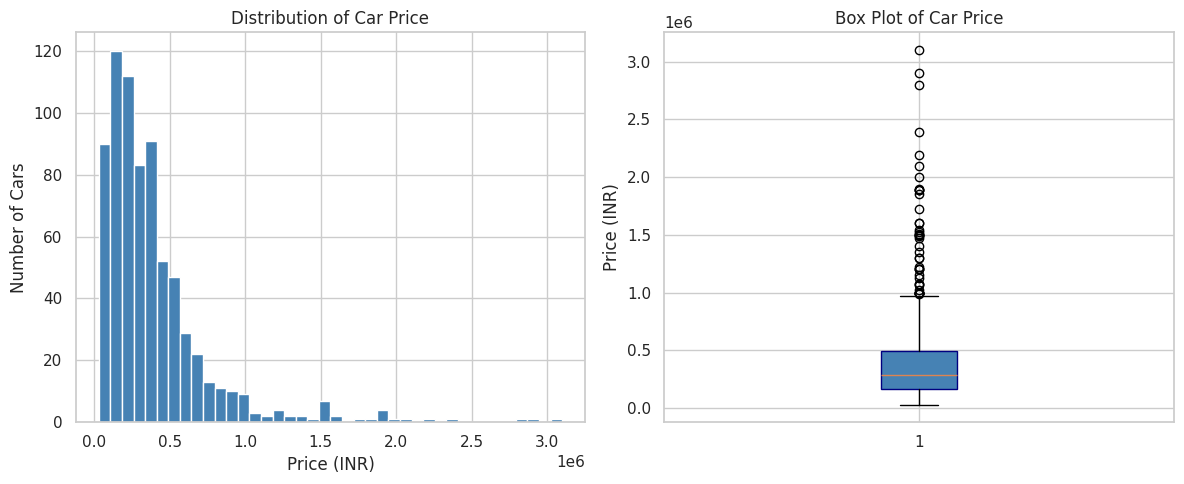

Price - Mean   : ₹392,516
Price - Median : ₹290,000
Price - Min    : ₹30,000
Price - Max    : ₹3,100,000


In [12]:
# --- Histogram of Price ---
# A histogram shows how often each price range appears

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['Price'], bins=40, color='steelblue', edgecolor='white')
plt.title('Distribution of Car Price')
plt.xlabel('Price (INR)')
plt.ylabel('Number of Cars')

# Box plot shows median, spread, and outliers
plt.subplot(1, 2, 2)
plt.boxplot(df['Price'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='steelblue', color='navy'))
plt.title('Box Plot of Car Price')
plt.ylabel('Price (INR)')

plt.tight_layout()
plt.show()

print(f'Price - Mean   : ₹{df["Price"].mean():,.0f}')
print(f'Price - Median : ₹{df["Price"].median():,.0f}')
print(f'Price - Min    : ₹{df["Price"].min():,.0f}')
print(f'Price - Max    : ₹{df["Price"].max():,.0f}')

**Observation:**  
- The price distribution is **right-skewed** — most cars are priced below ₹5 lakh, but a few luxury cars are priced very high.
- The median is lower than the mean, which confirms the skew.
- The box plot shows several **outliers** on the upper end (high-priced cars).

### 6.2 — Numerical Column: Year

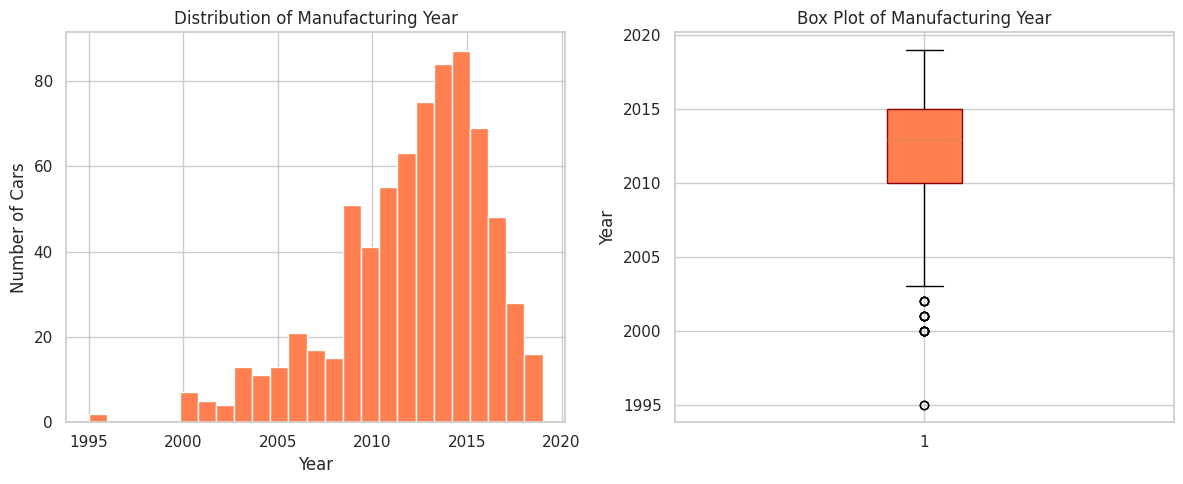

Most common year: 2015
Year range: 1995 to 2019


In [13]:
# --- Distribution of Year ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df['year'].hist(bins=25, color='coral', edgecolor='white')
plt.title('Distribution of Manufacturing Year')
plt.xlabel('Year')
plt.ylabel('Number of Cars')

plt.subplot(1, 2, 2)
plt.boxplot(df['year'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='coral', color='darkred'))
plt.title('Box Plot of Manufacturing Year')
plt.ylabel('Year')

plt.tight_layout()
plt.show()

print(f'Most common year: {df["year"].mode()[0]}')
print(f'Year range: {df["year"].min()} to {df["year"].max()}')

**Observation:**  
- Most used cars in the dataset were manufactured between 2010 and 2016.
- Very few cars are from before 2000 or after 2018.
- This tells us the dataset represents **recent used car market** data.

### 6.3 — Numerical Column: Kms Driven

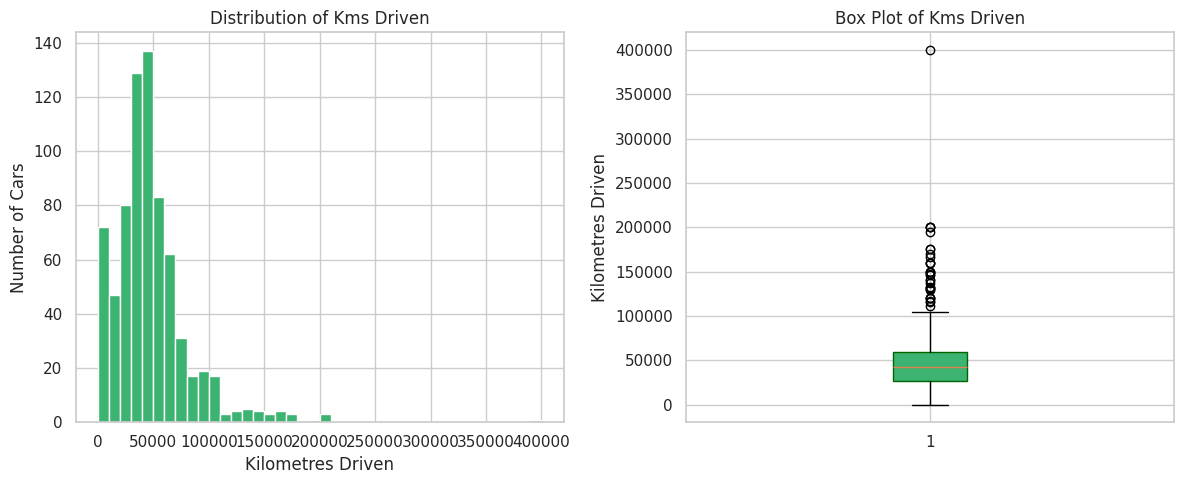

Average kms driven : 46,763 km
Max kms driven     : 400,000 km
Min kms driven     : 0 km


In [14]:
# --- Distribution of Kms Driven ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df['kms_driven'].hist(bins=40, color='mediumseagreen', edgecolor='white')
plt.title('Distribution of Kms Driven')
plt.xlabel('Kilometres Driven')
plt.ylabel('Number of Cars')

plt.subplot(1, 2, 2)
plt.boxplot(df['kms_driven'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='mediumseagreen', color='darkgreen'))
plt.title('Box Plot of Kms Driven')
plt.ylabel('Kilometres Driven')

plt.tight_layout()
plt.show()

print(f'Average kms driven : {df["kms_driven"].mean():,.0f} km')
print(f'Max kms driven     : {df["kms_driven"].max():,.0f} km')
print(f'Min kms driven     : {df["kms_driven"].min():,.0f} km')

**Observation:**  
- Most cars have been driven between 20,000 and 80,000 km.
- There are outliers with very high km readings (400,000 km) — heavily used vehicles.
- A few cars show 0 km — these might be nearly new cars being resold.

### 6.4 — Categorical Column: Company

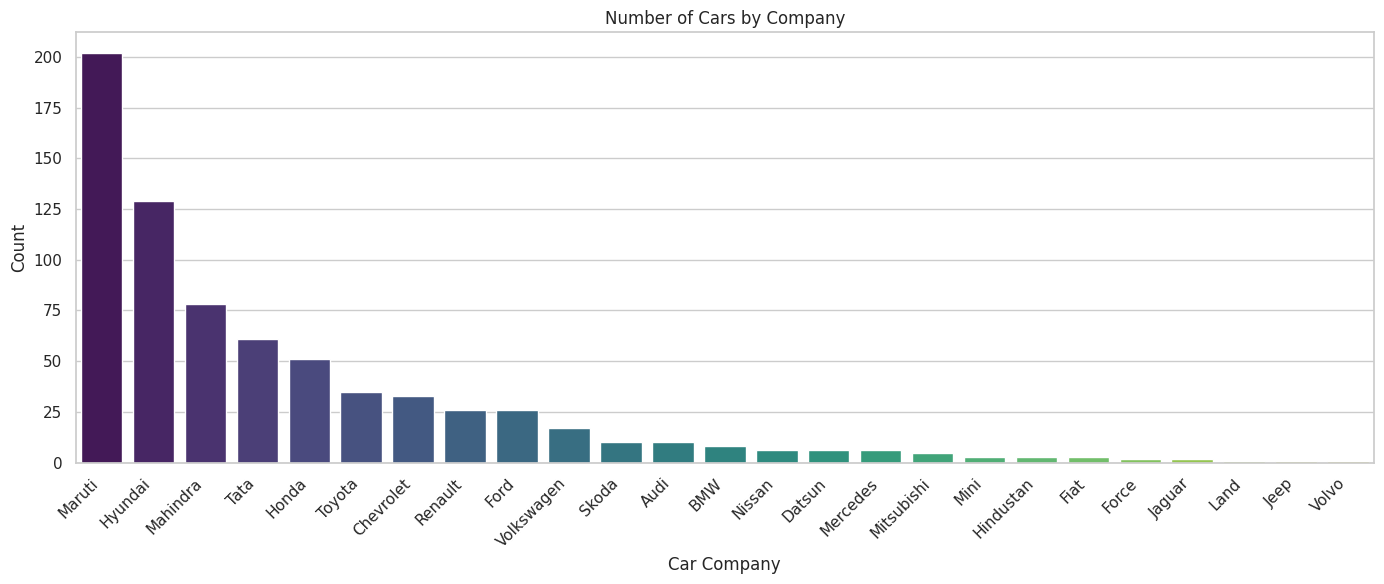


Car count per company:
company
Maruti        202
Hyundai       129
Mahindra       78
Tata           61
Honda          51
Toyota         35
Chevrolet      33
Renault        26
Ford           26
Volkswagen     17
Skoda          10
Audi           10
BMW             8
Nissan          6
Datsun          6
Mercedes        6
Mitsubishi      5
Mini            3
Hindustan       3
Fiat            3
Force           2
Jaguar          2
Land            1
Jeep            1
Volvo           1
Name: count, dtype: int64


In [15]:
# --- Count Plot for Company ---
# Count how many cars belong to each company
company_counts = df['company'].value_counts()

plt.figure(figsize=(14, 6))
sns.barplot(x=company_counts.index, y=company_counts.values, palette='viridis')
plt.title('Number of Cars by Company')
plt.xlabel('Car Company')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nCar count per company:')
print(company_counts)

**Observation:**  
- **Maruti** and **Hyundai** dominate the used car market — they are the most popular brands.
- Premium brands like **Audi**, **BMW**, and **Mercedes** have very few listings, which makes sense since fewer luxury cars are resold.
- This **class imbalance** in companies may affect encoding strategy.

### 6.5 — Categorical Column: Fuel Type

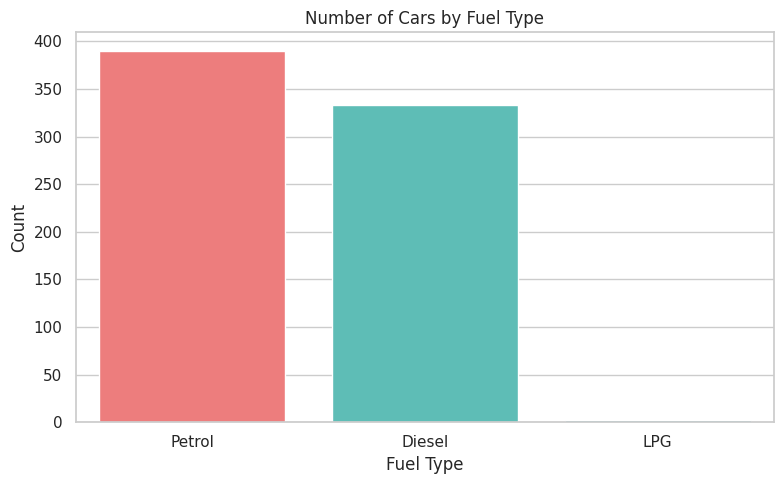

Fuel Type Distribution:
  Petrol   : 390 cars (53.8%)
  Diesel   : 333 cars (45.9%)
  LPG      : 2 cars (0.3%)


In [16]:
# --- Count Plot for Fuel Type ---
fuel_counts = df['fuel_type'].value_counts()

plt.figure(figsize=(8, 5))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
sns.barplot(x=fuel_counts.index, y=fuel_counts.values, palette=colors)
plt.title('Number of Cars by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print('Fuel Type Distribution:')
for fuel, count in fuel_counts.items():
    percentage = (count / len(df)) * 100
    print(f'  {fuel:8s} : {count} cars ({percentage:.1f}%)')

**Observation:**  
- **Petrol** cars are the most common, followed by **Diesel**.
- **LPG** cars are very rare in this dataset.
- This imbalance will be important to note when training the model.

---
## 📈 Step 7: Bivariate Analysis — Features vs. Price

**Bivariate** = two variables at a time.

We study how each feature **relates to the target variable (Price)**.

### 7.1 — Year vs. Price

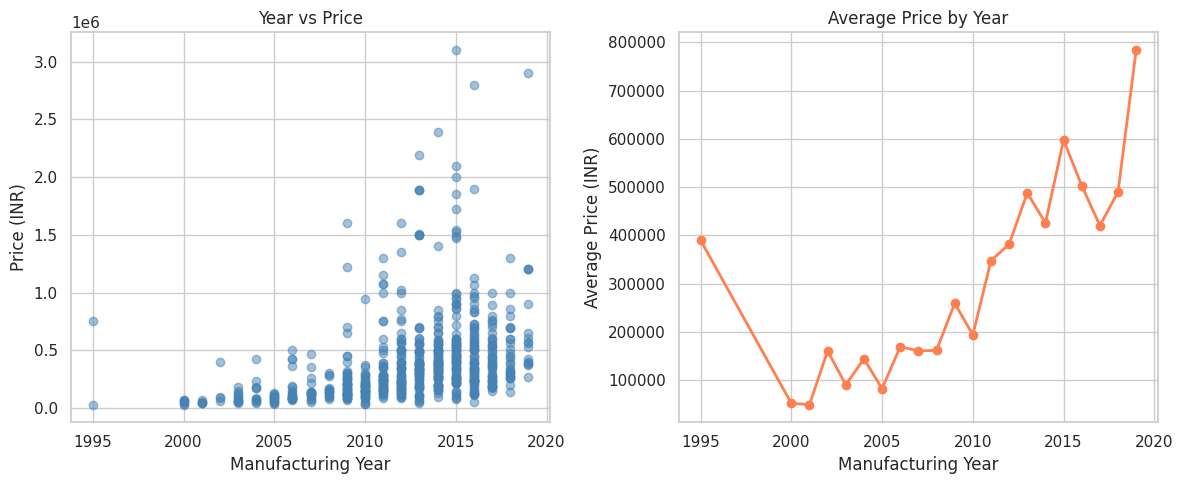

In [17]:
# --- Year vs Price ---
# We expect newer cars to cost more
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(df['year'], df['Price'], alpha=0.5, color='steelblue')
plt.title('Year vs Price')
plt.xlabel('Manufacturing Year')
plt.ylabel('Price (INR)')

# Group by year and compute average price
avg_price_by_year = df.groupby('year')['Price'].mean().reset_index()

plt.subplot(1, 2, 2)
plt.plot(avg_price_by_year['year'], avg_price_by_year['Price'],
         marker='o', color='coral', linewidth=2)
plt.title('Average Price by Year')
plt.xlabel('Manufacturing Year')
plt.ylabel('Average Price (INR)')

plt.tight_layout()
plt.show()

**Observation:**  
- Newer cars (manufactured after 2015) generally have **higher prices**.
- There is a clear **positive relationship** between year and price — this confirms that `year` is a useful feature.

### 7.2 — Kms Driven vs. Price

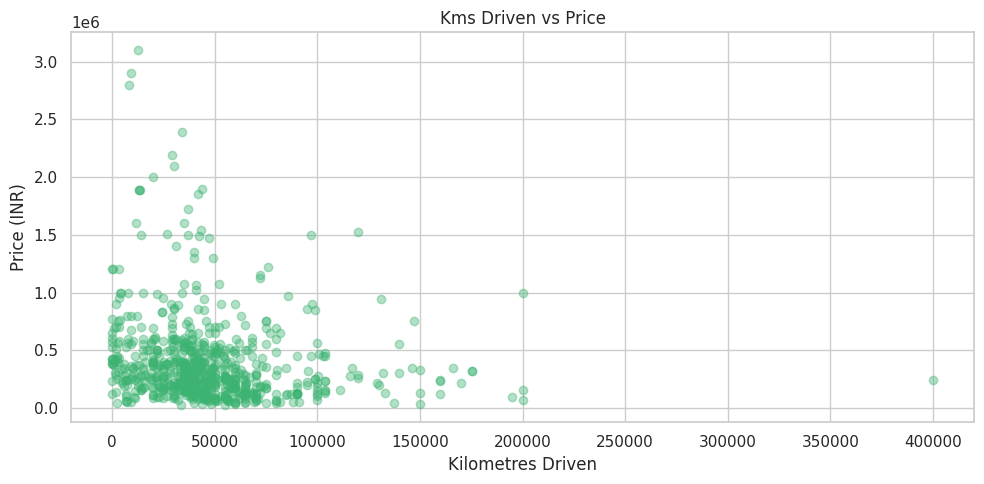

In [18]:
# --- Kms Driven vs Price ---
# We expect higher kms to mean lower price
plt.figure(figsize=(10, 5))
plt.scatter(df['kms_driven'], df['Price'], alpha=0.4, color='mediumseagreen')
plt.title('Kms Driven vs Price')
plt.xlabel('Kilometres Driven')
plt.ylabel('Price (INR)')
plt.tight_layout()
plt.show()

**Observation:**  
- Cars with fewer kilometres driven tend to be priced higher.
- The relationship has **high variance** — some heavily-driven cars still sell high.
- There are outliers at very high km values.

### 7.3 — Company vs. Average Price

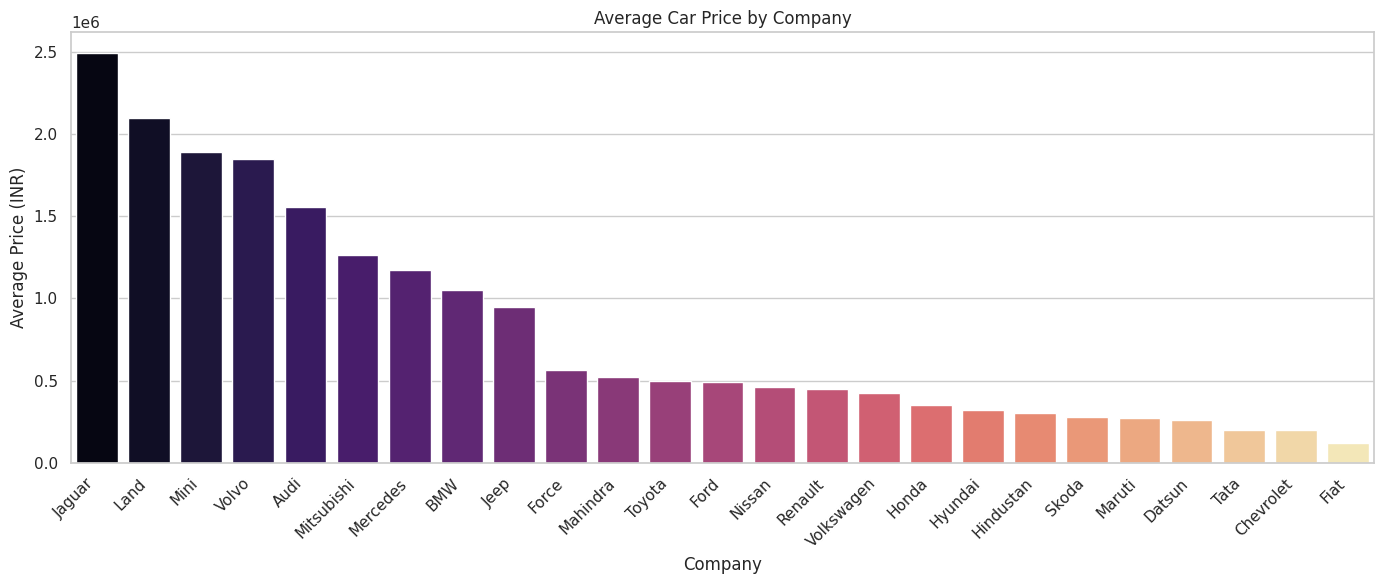

In [19]:
# --- Average Price by Company ---
avg_price_by_company = df.groupby('company')['Price'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=avg_price_by_company.index, y=avg_price_by_company.values, palette='magma')
plt.title('Average Car Price by Company')
plt.xlabel('Company')
plt.ylabel('Average Price (INR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Observation:**  
- **Audi, BMW, and Mercedes** command much higher average prices — they are luxury brands.
- **Maruti and Hyundai** have lower average prices — they are budget/mid-segment brands.
- The company name is a **strong predictor** of price.

### 7.4 — Fuel Type vs. Price

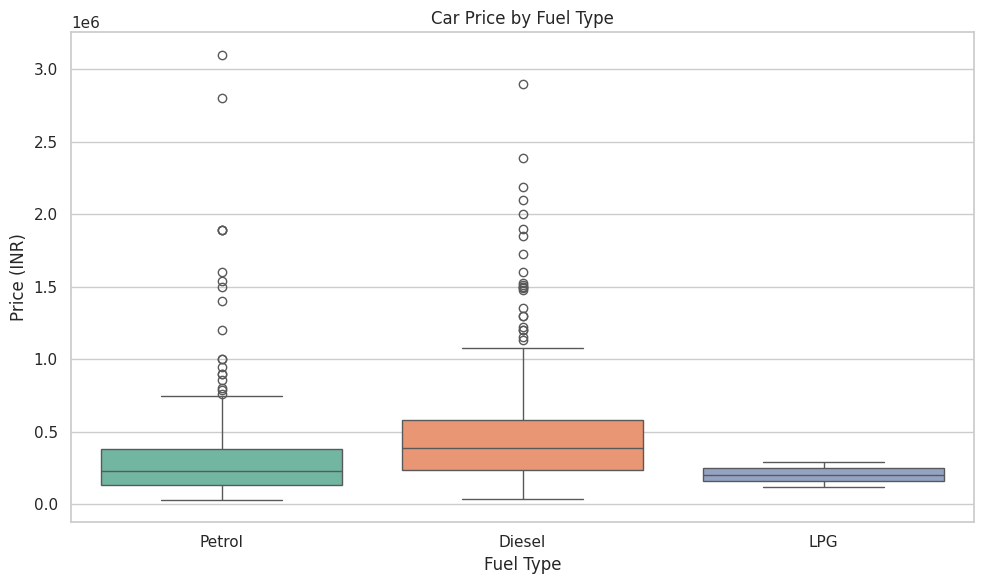

Average price by fuel type:
fuel_type
Diesel    492259.360360
Petrol    308312.964103
LPG       205000.000000
Name: Price, dtype: float64


In [20]:
# --- Fuel Type vs Price ---
plt.figure(figsize=(10, 6))
sns.boxplot(x='fuel_type', y='Price', data=df, palette='Set2')
plt.title('Car Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Price (INR)')
plt.tight_layout()
plt.show()

print('Average price by fuel type:')
print(df.groupby('fuel_type')['Price'].mean().sort_values(ascending=False))

**Observation:**  
- **Diesel** cars tend to have higher prices than Petrol cars on average.
- **LPG** cars are generally cheaper.
- Fuel type is a relevant feature for price prediction.

---
## 🔗 Step 8: Correlation Analysis

### What is Correlation?

Correlation measures the **strength and direction of a linear relationship** between two numerical variables.

- **+1.0** → Perfect positive correlation (both increase together)
- **0.0** → No correlation
- **-1.0** → Perfect negative correlation (one increases, other decreases)

### Why Correlation Matters for ML?

- Helps identify which features are most predictive of the target
- Detects **multicollinearity** — when two features are highly correlated with each other (this can hurt linear models)
- Helps with feature selection

In [21]:
# Calculate correlation matrix for numerical columns only
numerical_columns = ['year', 'Price', 'kms_driven']
correlation_matrix = df[numerical_columns].corr()

print('Correlation Matrix:')
print(correlation_matrix.round(3))

Correlation Matrix:
             year  Price  kms_driven
year        1.000  0.364      -0.250
Price       0.364  1.000      -0.157
kms_driven -0.250 -0.157       1.000


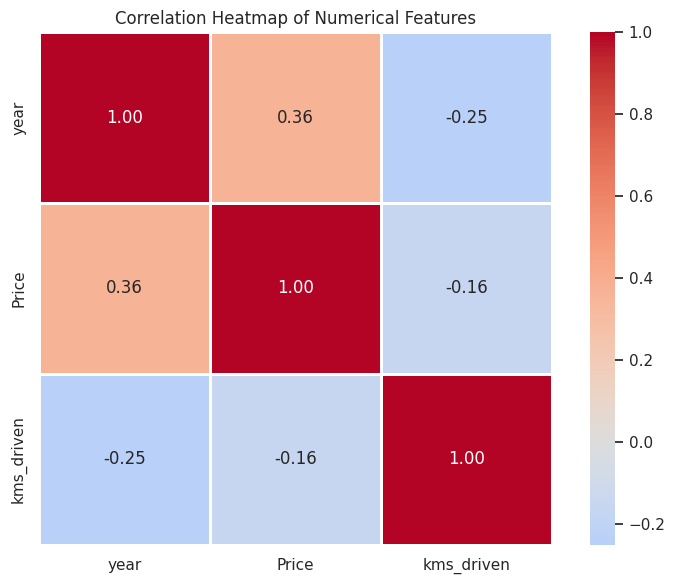

In [22]:
# --- Correlation Heatmap ---
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,           # Show correlation values inside cells
    fmt='.2f',            # 2 decimal places
    cmap='coolwarm',      # Blue = negative, Red = positive
    center=0,
    linewidths=1,
    square=True
)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

**Observations:**
- `year` has a **positive correlation** with `Price` — newer cars cost more ✅
- `kms_driven` has a **negative correlation** with `Price` — more driven = lower price ✅
- `year` and `kms_driven` have a moderate negative correlation — older cars have been driven more, which is expected

---
## ⚠️ Step 9: Outlier Analysis

### What are Outliers?

Outliers are **extreme values** that are very different from the majority of your data.  
Example: If most car prices are ₹1–5 lakh, a car priced at ₹31 lakh is an outlier.

### IQR Method for Detecting Outliers

The most common method:

```
Q1 = 25th percentile
Q3 = 75th percentile
IQR = Q3 - Q1

Lower fence = Q1 - 1.5 × IQR
Upper fence = Q3 + 1.5 × IQR

Any value outside these fences is an outlier.
```

### When to Remove vs. Keep Outliers?

| Situation | Action |
|-----------|--------|
| Outlier is a data entry error | Remove it |
| Outlier is a rare but valid data point (e.g., luxury car) | Keep it |
| Outlier distorts the model significantly | Remove or cap it |
| Tree-based models (Random Forest, XGBoost) | Generally robust to outliers |
| Linear Regression | Sensitive — outliers can heavily affect the line |

In [23]:
# --- IQR-based Outlier Detection ---
def detect_outliers_iqr(data, column_name):
    """
    Detect outliers in a numerical column using the IQR method.
    Returns the count and percentage of outliers.
    """
    Q1 = data[column_name].quantile(0.25)   # 25th percentile
    Q3 = data[column_name].quantile(0.75)   # 75th percentile
    IQR = Q3 - Q1                           # Interquartile Range

    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR

    # Find rows where the value is outside the fences
    outliers = data[(data[column_name] < lower_fence) | (data[column_name] > upper_fence)]

    outlier_count = len(outliers)
    outlier_percent = (outlier_count / len(data)) * 100

    print(f'Column       : {column_name}')
    print(f'Q1           : {Q1:,.0f}')
    print(f'Q3           : {Q3:,.0f}')
    print(f'IQR          : {IQR:,.0f}')
    print(f'Lower Fence  : {lower_fence:,.0f}')
    print(f'Upper Fence  : {upper_fence:,.0f}')
    print(f'Outliers     : {outlier_count} rows ({outlier_percent:.1f}%)')
    print('-' * 40)

    return outliers


# Check outliers in numerical columns
print('=' * 40)
print('OUTLIER ANALYSIS')
print('=' * 40)
price_outliers = detect_outliers_iqr(df, 'Price')
kms_outliers = detect_outliers_iqr(df, 'kms_driven')
year_outliers = detect_outliers_iqr(df, 'year')

OUTLIER ANALYSIS
Column       : Price
Q1           : 165,000
Q3           : 489,999
IQR          : 324,999
Lower Fence  : -322,498
Upper Fence  : 977,498
Outliers     : 44 rows (6.1%)
----------------------------------------
Column       : kms_driven
Q1           : 27,000
Q3           : 59,000
IQR          : 32,000
Lower Fence  : -21,000
Upper Fence  : 107,000
Outliers     : 31 rows (4.3%)
----------------------------------------
Column       : year
Q1           : 2,010
Q3           : 2,015
IQR          : 5
Lower Fence  : 2,002
Upper Fence  : 2,022
Outliers     : 18 rows (2.5%)
----------------------------------------


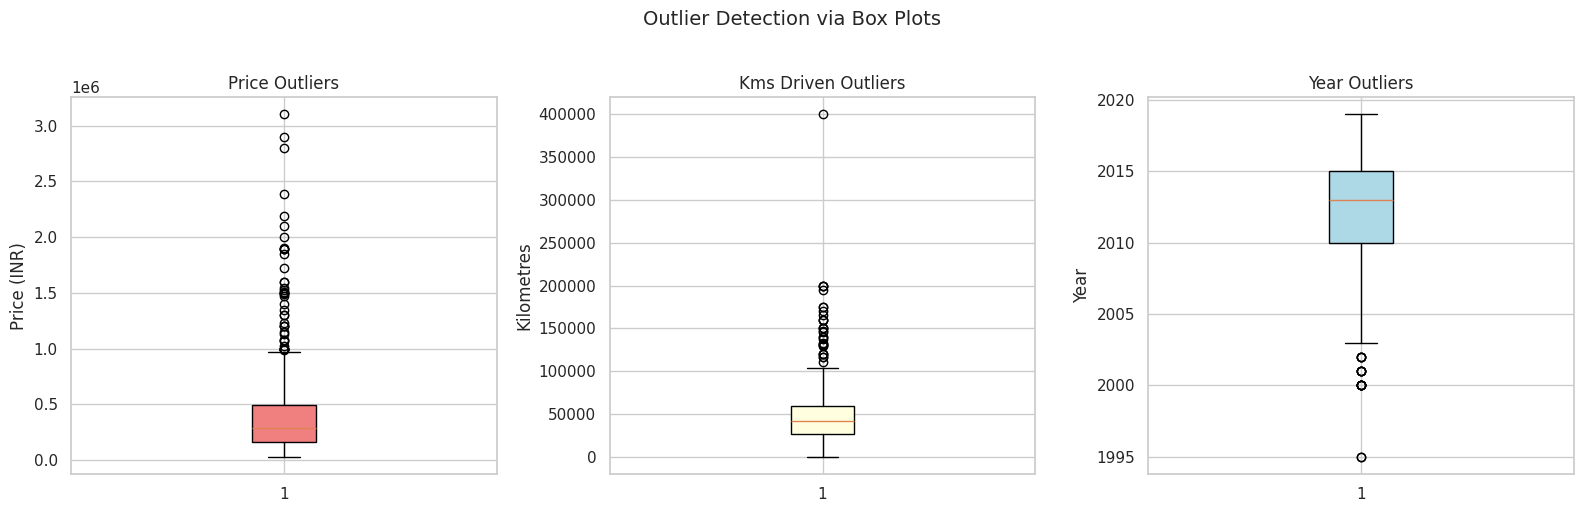


Decision on Outliers:
- Price outliers: HIGH-PRICED luxury cars are valid data. We KEEP them.
- Kms outliers  : Very high km cars are rare but valid. We KEEP them.
- Year outliers : Very old cars are rare but genuine. We KEEP them.
- Tree-based models (Random Forest, Gradient Boosting) handle outliers well.


In [24]:
# --- Visualize outliers using box plots ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].boxplot(df['Price'], patch_artist=True,
                boxprops=dict(facecolor='lightcoral'))
axes[0].set_title('Price Outliers')
axes[0].set_ylabel('Price (INR)')

axes[1].boxplot(df['kms_driven'], patch_artist=True,
                boxprops=dict(facecolor='lightyellow'))
axes[1].set_title('Kms Driven Outliers')
axes[1].set_ylabel('Kilometres')

axes[2].boxplot(df['year'], patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[2].set_title('Year Outliers')
axes[2].set_ylabel('Year')

plt.suptitle('Outlier Detection via Box Plots', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print()
print('Decision on Outliers:')
print('- Price outliers: HIGH-PRICED luxury cars are valid data. We KEEP them.')
print('- Kms outliers  : Very high km cars are rare but valid. We KEEP them.')
print('- Year outliers : Very old cars are rare but genuine. We KEEP them.')
print('- Tree-based models (Random Forest, Gradient Boosting) handle outliers well.')

---
## 📋 Step 10: EDA Summary

Let us summarize all important observations from our EDA:

| Finding | Detail |
|---------|--------|
| Dataset Shape | 725 rows × 6 columns |
| Missing Values | None — dataset is clean |
| Duplicates | None found |
| Target Variable | `Price` — right-skewed distribution |
| Most Common Company | Maruti, Hyundai |
| Dominant Fuel Type | Petrol |
| Year Range | 1995 to 2019 |
| Key Positive Correlation | `year` ↑ → `Price` ↑ |
| Key Negative Correlation | `kms_driven` ↑ → `Price` ↓ |
| Outliers | Present in Price & kms_driven — valid data, keep them |
| High-Impact Features | `company`, `year`, `fuel_type`, `kms_driven` |
| Low-Value Feature | `name` — too many unique values, overlaps with `company` |

---
## 🎯 Interview Questions

**Q1. What is the purpose of EDA in a Machine Learning project?**  
> EDA helps us understand the data before building a model. It reveals data quality issues, distributions, relationships between variables, and helps in choosing the right preprocessing and modeling strategy. Skipping EDA often leads to poor model performance.

**Q2. What is the difference between mean and median? When should you prefer median?**  
> Mean is the arithmetic average; median is the middle value. When data is skewed (like car prices), the mean is pulled toward extreme values. Median is more robust to outliers, so it better represents the 'typical' value in skewed distributions.

**Q3. What is the IQR method for outlier detection?**  
> IQR = Q3 − Q1. Any value below Q1 − 1.5×IQR or above Q3 + 1.5×IQR is considered an outlier. It's a non-parametric method that doesn't assume a normal distribution.

**Q4. When should you remove outliers and when should you keep them?**  
> Remove outliers that are data entry errors or noise. Keep outliers that represent valid, rare real-world events (like luxury car prices). The decision depends on domain knowledge and which algorithm you use — tree-based models are robust to outliers, but linear models are sensitive.

**Q5. What is the difference between univariate and bivariate analysis?**  
> Univariate analysis examines one variable at a time (e.g., distribution of price). Bivariate analysis examines the relationship between two variables (e.g., how price changes with year). Both are necessary for a complete understanding of the dataset.

---
## ❌ Common Beginner Mistakes in EDA

1. **Jumping to modeling without EDA** — You'll miss data quality issues that corrupt your model.
2. **Treating all outliers as errors** — High car prices might be valid luxury entries; always verify with domain context.
3. **Ignoring categorical variables in EDA** — Count plots and group-by analyses often reveal the strongest signals.
4. **Confusing correlation with causation** — High kms and low price are correlated, but kms alone don't *cause* low price; age is also a factor.
5. **Not looking at target variable distribution** — A skewed target (like Price) may require log transformation before training linear models.